## 实验3.1 绘制ROC曲线及P-R曲线

### 1、加载、拆分breast_cancer数据集

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 加载breast_cancer数据集
cancer = load_breast_cancer()

# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    test_size=0.25, random_state=0)


### 2、建立SVC模型，绘制ROC曲线

+ ROC曲线以假正率（FPR）和真正率（TPR）为X轴和y轴。
+ TPR(True Positive Rate): 真正率(灵敏度)，越大越好，1为理想状态。计算公式：TPR=TP/(TP+FN)。
+ FPR(False Positive Rate): 假正率(特异度)，越小越好，0为理想状态。计算公式：FPR=FP/(FP+TN)。
+ ROC曲线下方的面积叫做AUC(Area Under Curve-曲线下面积)，其值越大模型性能越好。

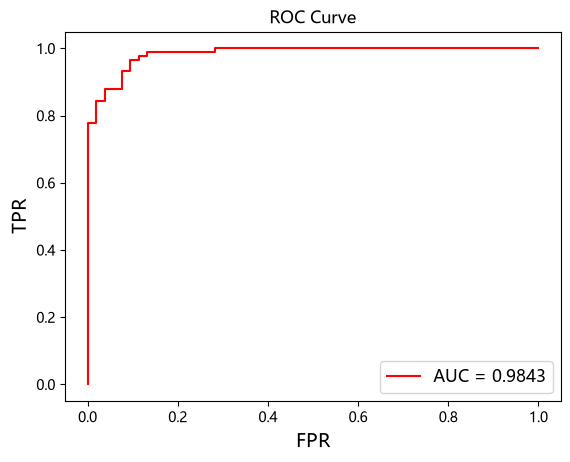

In [3]:
from sklearn.svm import SVC # 导入SVC
from sklearn.metrics import roc_curve, auc # 导入 ROC 、AUC

model = SVC().fit(X_train, y_train) # 创建SVC模型，拟合训练数据

y_score = model.decision_function(X_test) # 计算样本点到分割面的函数距离
fpr, tpr, threshold = roc_curve(y_test, y_score) # 计算假正率、真正率、阈值
auc2 = auc(fpr, tpr) # 计算auc面积，auc值越接近1模型性能越好
# 绘制ROC曲线
plt.title('ROC Curve') # 标题
plt.xlabel('FPR', fontsize=14) # x轴标签
plt.ylabel('TPR', fontsize=14) # y轴标签
plt.plot(fpr, tpr, label='AUC = %0.4f'%auc2, c='r') # 划线
plt.legend(fontsize=12) # 图例

plt.show()


#### 2.1 不同模型的ROC曲线比较 （选做）
+ 使用不同的参数定义三个模型，比较其ROC曲线
+ ROC曲线越靠近左上角（auc面积越大），模型性能越好

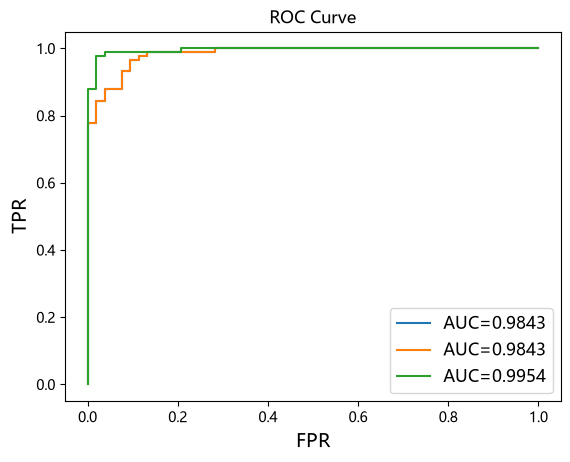

In [4]:
model_1 = SVC(gamma='scale').fit(X_train, y_train) # 创建SVC模型，拟合训练数据,设置核函数的系数为'scale'
model_2 = SVC().fit(X_train, y_train) # 创建SVC模型，拟合训练数据
model_3 = SVC(kernel='linear').fit(X_train, y_train) # 创建SVC模型，拟合训练数据,核函数为'线性核函数'
models = [model_1, model_2, model_3]

# 绘制ROC曲线
plt.title('ROC Curve') # 标题
for m in models:
    y_score = m.decision_function(X_test) # 计算样本点到分割面的函数距离
    fpr, tpr, threshold = roc_curve(y_test, y_score) # 计算假正率、真正率、阈值
    plt.xlabel('FPR', fontsize=14) # x轴标签
    plt.ylabel('TPR', fontsize=14) # y轴标签
    plt.plot(fpr, tpr, label='AUC=%0.4f'%auc(fpr, tpr)) # 划线

plt.legend(fontsize=12) # 图例
plt.show()


### 3、绘制P-R曲线（精确率-召回率曲线）
+ P-R曲线反映了精确率和召回率之间的关系
+ P-R曲线越凸向右上方，表示模型性能越好

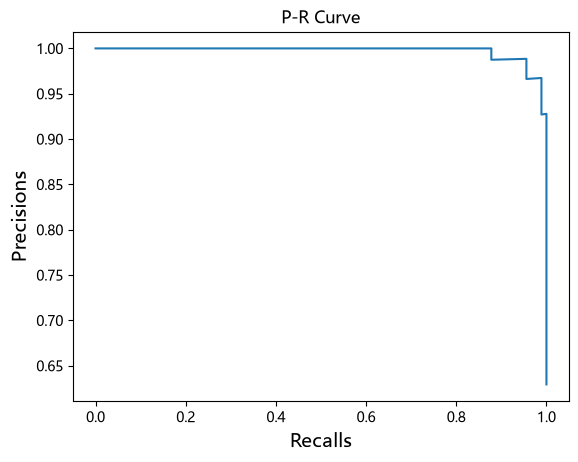

In [5]:
from sklearn.linear_model import LogisticRegression # 导入LR模块
from sklearn.metrics import precision_recall_curve # P-R曲线计算函数

model = LogisticRegression(max_iter=10000).fit(X_train, y_train) # 创建LR模型，拟合训练数据

y_score = model.decision_function(X_test) # 计算样本点到分割面的函数距离

# PR曲线计算函数（返回值为精确率、召回率、阈值，参数为测试集和上述距离）
precisions, recalls, thresholds = precision_recall_curve(y_test, y_score)

plt.title('P-R Curve') # 标题
plt.xlabel('Recalls', fontsize=14) # x轴标签
plt.ylabel('Precisions', fontsize=14) # y轴标签
plt.plot(recalls, precisions) # 画线
plt.show()
